### <font color='white'>Objective: </font>

In this assignment, you will implement and evaluate a K-Nearest Neighbors (KNN) regression model using a toy dataset generated with scikit-learn. You will implement with scikit-learn's built-in KNN regression and analyze the performance.

#### Task - 1:
Dataset creation using make_regression of scikit-learn [Mark - 0]



In [1]:
# import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from pprint import pp

from tqdm import tqdm

In [2]:
# create toy dataset using make_regression function from sklearn.datasets
toy_dataset = make_regression(n_samples=200, n_features=25, random_state=42, coef=False)
X = toy_dataset[0]
y = toy_dataset[1]

### Explore toy dataset

In [3]:
# The shape should show number of samples and number of features for X, and number of samples for y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (200, 25)
Shape of y: (200,)


### Split dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.50, random_state=42)

In [5]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (150, 25) (150,)
Validation set shape: (25, 25) (25,)
Test set shape: (25, 25) (25,)


In [6]:
# Standard scale the data
scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

#### Task - 2:
Two K-NN regressor implementations (from scratch)
1. Average of K-nearest neighbors [Marks - 5]
2. Weighted average of k nearest neighbors, with weights being inverse of distances from the k neighbors [Marks - 5]

In [7]:
def minkowski_distance(x, y, p=2) -> float:
    return np.sum(np.abs(x - y) ** p) ** (1 / p)

def cosine_similarity(x, y) -> float:
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

def chebyshev_distance(x, y) -> float:
    return np.max(np.abs(x - y))

In [8]:
class KNNRegressor:
    """
    A custom implementation of the K-Nearest Neighbors (KNN) regression algorithm from scratch.
    This is based on the implementation given in the class notebook. The prediction method is the only thing changed.
    Changed from taking maximum number of neighbours to averaging them
    """
    def __init__(self, k=3, distance_metric='euclidean', p=2, weighted=False):
        self.k = k
        self.distance_metric = distance_metric
        self.p = p
        self.weighted = weighted

    def fit_knn(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def _compute_distance(self, x):
        if self.distance_metric == 'minkowski':
            distances = [minkowski_distance(x, x_train, p=self.p) for x_train in self.X_train]
        elif self.distance_metric == 'chebyshev':
            distances = [chebyshev_distance(x, x_train) for x_train in self.X_train]
        else:
            raise ValueError("Unsupported distance metric")
        return distances

    def predict_knn(self, X_test):
        predictions = []
        for x in tqdm(X_test):
            distances = self._compute_distance(x)
            k_indices = np.argsort(distances)[:self.k]  # lowest distances
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            if self.weighted:
                k_distances = [distances[i] for i in k_indices]
                weights = 1 / (np.array(k_distances) + 1e-8)  # Avoid division by zero
                # Perform weighted average of the k nearest labels
                prediction = np.average(k_nearest_labels, weights=weights)
            else:
                prediction = np.mean(k_nearest_labels)
            predictions.append(prediction)
        return predictions

#### Task - 3:
Plot regression metric (mean squared error) against different values of k ``` {3, 7, 11}``` and different distance measures ```{p=2, p=1, p=5}```and report the k value and distance measure combination that gave the best performance (lowest MSE) [Marks - 4]

### Non-weighted KNN regression implementation

In [9]:
k_values = [3, 7, 11]
d_values = [2, 1, 5]

# Dictionary to store results for non-weighted KNN Regressor
results_data_non_weighted = {}

for k in k_values:
    for d in d_values:
        print(f"Evaluating non-weighted KNN Regressor with k={k} and d={d}")
        knn_regressor = KNNRegressor(k=k, distance_metric='minkowski', p=d)
        knn_regressor.fit_knn(X_train, y_train)

        # Predict on validation set
        y_val_pred = knn_regressor.predict_knn(X_val)
        val_mse = mean_squared_error(y_val, y_val_pred)

        # Predict on test set
        y_test_pred = knn_regressor.predict_knn(X_test)
        test_mse = mean_squared_error(y_test, y_test_pred)

        result_key = f"k:{k}, d:{d}"
        results_data_non_weighted[result_key] = (val_mse, test_mse)

Evaluating non-weighted KNN Regressor with k=3 and d=2


100%|██████████| 25/25 [00:00<00:00, 2904.16it/s]


Evaluating non-weighted KNN Regressor with k=3 and d=1


100%|██████████| 25/25 [00:00<00:00, 1855.43it/s]


Evaluating non-weighted KNN Regressor with k=3 and d=5


...

100%|██████████| 25/25 [00:00<00:00, 2305.22it/s]


Evaluating non-weighted KNN Regressor with k=11 and d=1


100%|██████████| 25/25 [00:00<00:00, 1968.42it/s]


Evaluating non-weighted KNN Regressor with k=11 and d=5


100%|██████████| 25/25 [00:00<00:00, 2415.07it/s]


### Weighted KNN regression implementation

In [10]:
# Dictionary to store results for weighted KNN Regressor
results_data_weighted = {}

for k in k_values:
    for d in d_values:
        print(f"Evaluating weighted KNN Regressor with k={k} and d={d}")
        knn_regressor = KNNRegressor(k=k, distance_metric='minkowski', p=d, weighted=True)
        knn_regressor.fit_knn(X_train, y_train)

        # Predict on validation set
        y_val_pred = knn_regressor.predict_knn(X_val)
        val_mse = mean_squared_error(y_val, y_val_pred)

        # Predict on test set
        y_test_pred = knn_regressor.predict_knn(X_test)
        test_mse = mean_squared_error(y_test, y_test_pred)

        result_key = f"k:{k}, d:{d}"
        results_data_weighted[result_key] = (val_mse, test_mse)

Evaluating weighted KNN Regressor with k=3 and d=2


100%|██████████| 25/25 [00:00<00:00, 2818.90it/s]


Evaluating weighted KNN Regressor with k=3 and d=1


100%|██████████| 25/25 [00:00<00:00, 2052.69it/s]


Evaluating weighted KNN Regressor with k=3 and d=5


...

100%|██████████| 25/25 [00:00<00:00, 2257.28it/s]


Evaluating weighted KNN Regressor with k=11 and d=1


100%|██████████| 25/25 [00:00<00:00, 1798.96it/s]


Evaluating weighted KNN Regressor with k=11 and d=5


100%|██████████| 25/25 [00:00<00:00, 2035.20it/s]


### Show all results

In [11]:
# Show raw results for all combinations of k and d
print("Non-weighted KNN Regression Results:")
pp(results_data_non_weighted)

print("\nWeighted KNN Regression Results:")
pp(results_data_weighted)

Non-weighted KNN Regression Results:
{'k:3, d:2': (11836.366005134156, 10659.164429834289),
 'k:3, d:1': (13566.846145886413, 9291.623604202754),
 'k:3, d:5': (11093.150168861228, 10379.43892995417),
 'k:7, d:2': (12670.94465222836, 7465.53083829205),
 'k:7, d:1': (13930.924939619757, 7931.632469801963),
 'k:7, d:5': (12246.73510122602, 8749.730410250664),
 'k:11, d:2': (11970.882613267377, 6903.138908697911),
 'k:11, d:1': (12212.11963588019, 8750.47401670027),
 'k:11, d:5': (12650.53676240578, 8983.386074665628)}

Weighted KNN Regression Results:
{'k:3, d:2': (11723.527127703344, 10318.880503650376),
 'k:3, d:1': (13496.712185208253, 9204.722525752273),
 'k:3, d:5': (10734.49030799482, 10075.512574520744),
 'k:7, d:2': (12399.048961836428, 7334.7820974467895),
 'k:7, d:1': (13750.832517663364, 7848.990961402741),
 'k:7, d:5': (12005.029617236285, 8487.129311035247),
 'k:11, d:2': (11804.714875522328, 6793.413975307607),
 'k:11, d:1': (12111.078641587386, 8601.30818998812),
 'k:11, d:

Processing output data and keeping only Test loss for evaluation of the model.

In [12]:
results_data_non_weighted_df = pd.DataFrame.from_dict(results_data_non_weighted, orient='index', columns=['Validation MSE', 'Test MSE']).drop(columns=['Validation MSE'])
results_data_weighted_df = pd.DataFrame.from_dict(results_data_weighted, orient='index', columns=['Validation MSE', 'Test MSE']).drop(columns=['Validation MSE'])

results_data_non_weighted_df.index.name = 'label'
results_data_non_weighted_df.reset_index(inplace=True)

results_data_weighted_df.index.name = 'label'
results_data_weighted_df.reset_index(inplace=True)

C:\Users\shamb\AppData\Local\Temp\ipykernel_33788\144484488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_data_non_weighted_df, x="label", y="Test MSE", palette='viridis')


<Axes: xlabel='label', ylabel='Test MSE'>

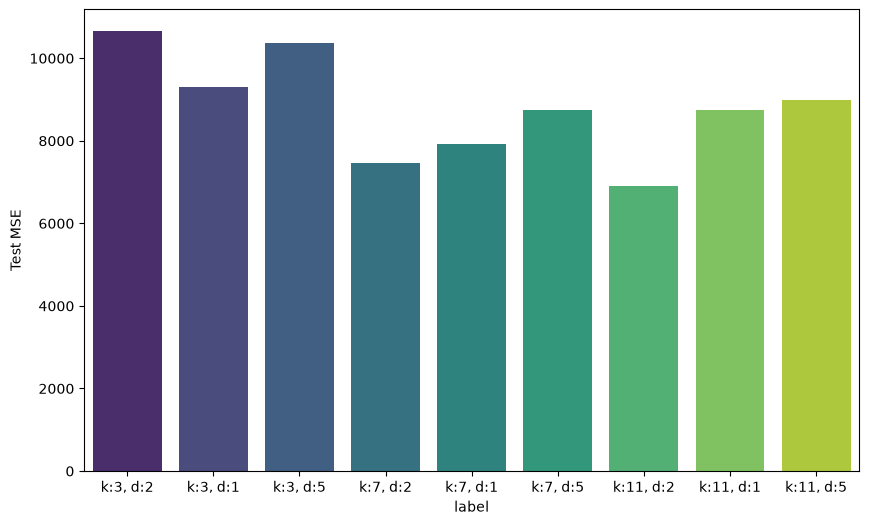

In [13]:
# Plot 1 with for non-weighted KNN Regressor
plt.figure(figsize=(10, 6))
sns.barplot(data=results_data_non_weighted_df, x="label", y="Test MSE", palette='viridis')

C:\Users\shamb\AppData\Local\Temp\ipykernel_33788\905087994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_data_weighted_df, x="label", y="Test MSE", palette='viridis')


<Axes: xlabel='label', ylabel='Test MSE'>

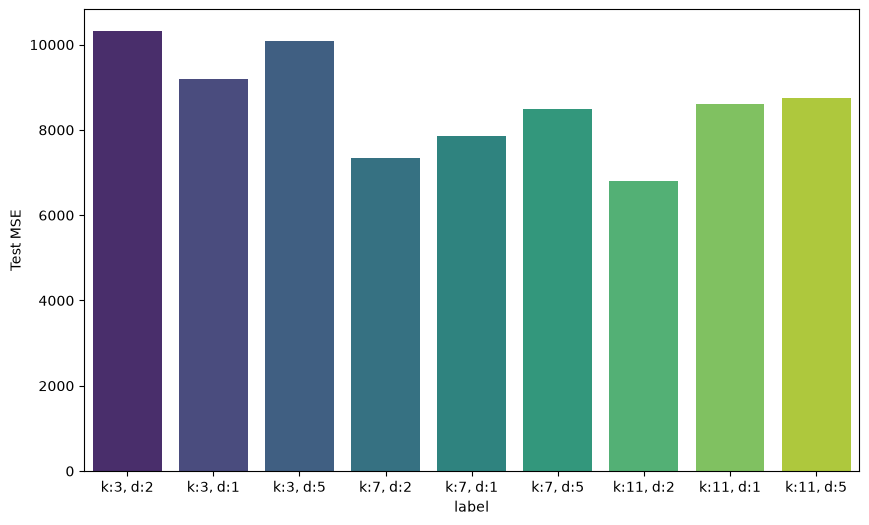

In [14]:
# Plot 2 for weighted KNN Regressor
plt.figure(figsize=(10, 6))
sns.barplot(data=results_data_weighted_df, x="label", y="Test MSE", palette='viridis')

In [15]:
# Best MSE for both cases based on test results
test_mse_values_non_weighted = [mse[1] for mse in results_data_non_weighted.values()]
min_mse_index = np.argmin(test_mse_values_non_weighted)
best_non_weighted_mse = test_mse_values_non_weighted[min_mse_index]
best_non_weighted_params = list(results_data_non_weighted.keys())[min_mse_index]

test_mse_values_weighted = [mse[1] for mse in results_data_weighted.values()]
min_mse_index = np.argmin(test_mse_values_weighted)
best_weighted_mse = test_mse_values_weighted[min_mse_index]
best_weighted_params = list(results_data_weighted.keys())[min_mse_index]

print(f"Best non-weighted KNN Regressor MSE: {best_non_weighted_mse:.4f} with parameters: {best_non_weighted_params}")
print(f"Best weighted KNN Regressor MSE: {best_weighted_mse:.4f} with parameters: {best_weighted_params}")

Best non-weighted KNN Regressor MSE: 6903.1389 with parameters: k:11, d:2
Best weighted KNN Regressor MSE: 6793.4140 with parameters: k:11, d:2


#### Task - 4:
Implement KNN regression using scikit-learn, with the same values of k and p as above

##### Note - one argument of scikit-learn KNN is ```algorithm='auto'``` and acceptable values are ```{'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto' ```. For this task use ```'brute'``` setting.

[Marks - 4]

In [16]:
k_values = [3, 7, 11]
d_values = [2, 1, 5]

results_data_non_weighted_skl = {}

for k in k_values:
    for d in d_values:
        print(f"Evaluating non-weighted KNN Regressor with k={k} and d={d}")
        knn_regressor = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=d, algorithm='brute').fit(X_train, y_train)
        val_preds = knn_regressor.predict(X_val)
        test_preds = knn_regressor.predict(X_test)
        val_mse = mean_squared_error(y_val, val_preds)
        test_mse = mean_squared_error(y_test, test_preds)
        result_key = f"k:{k}, d:{d}"
        results_data_non_weighted_skl[result_key] = (val_mse, test_mse)

Evaluating non-weighted KNN Regressor with k=3 and d=2
Evaluating non-weighted KNN Regressor with k=3 and d=1
Evaluating non-weighted KNN Regressor with k=3 and d=5
Evaluating non-weighted KNN Regressor with k=7 and d=2
Evaluating non-weighted KNN Regressor with k=7 and d=1
Evaluating non-weighted KNN Regressor with k=7 and d=5
Evaluating non-weighted KNN Regressor with k=11 and d=2
Evaluating non-weighted KNN Regressor with k=11 and d=1
Evaluating non-weighted KNN Regressor with k=11 and d=5


In [17]:
k_values = [3, 7, 11]
d_values = [2, 1, 5]

results_data_weighted_skl = {}

for k in k_values:
    for d in d_values:
        print(f"Evaluating weighted KNN Regressor with k={k} and d={d}")
        knn_regressor = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=d, algorithm='brute', weights='distance').fit(X_train, y_train)
        val_preds = knn_regressor.predict(X_val)
        test_preds = knn_regressor.predict(X_test)
        val_mse = mean_squared_error(y_val, val_preds)
        test_mse = mean_squared_error(y_test, test_preds)
        result_key = f"k:{k}, d:{d}"
        results_data_weighted_skl[result_key] = (val_mse, test_mse)

Evaluating weighted KNN Regressor with k=3 and d=2
Evaluating weighted KNN Regressor with k=3 and d=1
Evaluating weighted KNN Regressor with k=3 and d=5
Evaluating weighted KNN Regressor with k=7 and d=2
Evaluating weighted KNN Regressor with k=7 and d=1
Evaluating weighted KNN Regressor with k=7 and d=5
Evaluating weighted KNN Regressor with k=11 and d=2
Evaluating weighted KNN Regressor with k=11 and d=1
Evaluating weighted KNN Regressor with k=11 and d=5


### Show all results

In [18]:
print("Non-weighted KNN Regression Results:")
pp(results_data_non_weighted_skl)

print("\nWeighted KNN Regression Results:")
pp(results_data_weighted_skl)

Non-weighted KNN Regression Results:
{'k:3, d:2': (11836.366005134156, 10659.164429834289),
 'k:3, d:1': (13566.846145886413, 9291.623604202754),
 'k:3, d:5': (11093.150168861228, 10379.43892995417),
 'k:7, d:2': (12670.94465222836, 7465.53083829205),
 'k:7, d:1': (13930.924939619757, 7931.632469801963),
 'k:7, d:5': (12246.73510122602, 8749.730410250664),
 'k:11, d:2': (11970.882613267377, 6903.138908697911),
 'k:11, d:1': (12212.11963588019, 8750.47401670027),
 'k:11, d:5': (12650.53676240578, 8983.386074665628)}

Weighted KNN Regression Results:
{'k:3, d:2': (11723.527127507177, 10318.880502967377),
 'k:3, d:1': (13496.71218518422, 9204.722525713929),
 'k:3, d:5': (10734.4903065764, 10075.512573407363),
 'k:7, d:2': (12399.048961296818, 7334.782097171951),
 'k:7, d:1': (13750.832517570236, 7848.9909613646505),
 'k:7, d:5': (12005.02961628911, 8487.129310015824),
 'k:11, d:2': (11804.714875190377, 6793.413975069715),
 'k:11, d:1': (12111.078641527625, 8601.308189914655),
 'k:11, d:5'

In [19]:
results_data_non_weighted_df = pd.DataFrame.from_dict(results_data_non_weighted_skl, orient='index', columns=['Validation MSE', 'Test MSE']).drop(columns=['Validation MSE'])
results_data_weighted_df = pd.DataFrame.from_dict(results_data_weighted_skl, orient='index', columns=['Validation MSE', 'Test MSE']).drop(columns=['Validation MSE'])

results_data_non_weighted_df.index.name = 'label'
results_data_non_weighted_df.reset_index(inplace=True)

results_data_weighted_df.index.name = 'label'
results_data_weighted_df.reset_index(inplace=True)

C:\Users\shamb\AppData\Local\Temp\ipykernel_33788\144484488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_data_non_weighted_df, x="label", y="Test MSE", palette='viridis')


<Axes: xlabel='label', ylabel='Test MSE'>

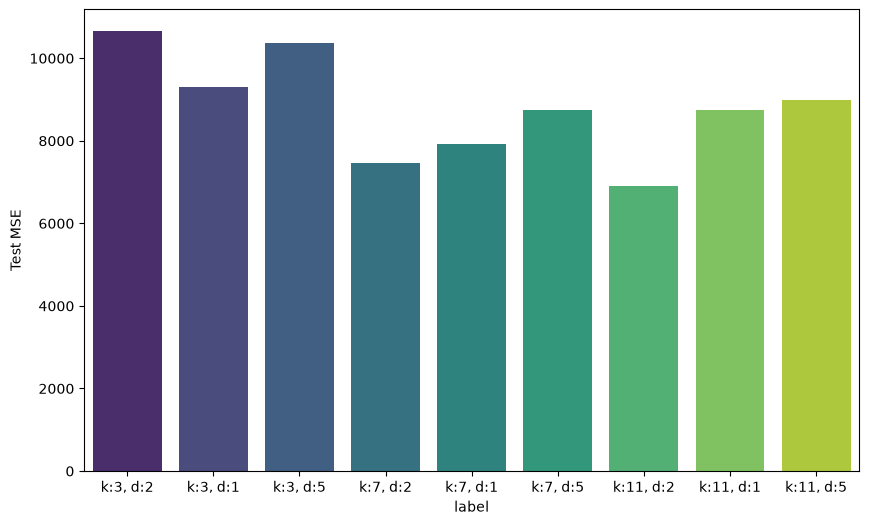

In [20]:
# Plot 1 with for non-weighted KNN Regressor
plt.figure(figsize=(10, 6))
sns.barplot(data=results_data_non_weighted_df, x="label", y="Test MSE", palette='viridis')

C:\Users\shamb\AppData\Local\Temp\ipykernel_33788\905087994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_data_weighted_df, x="label", y="Test MSE", palette='viridis')


<Axes: xlabel='label', ylabel='Test MSE'>

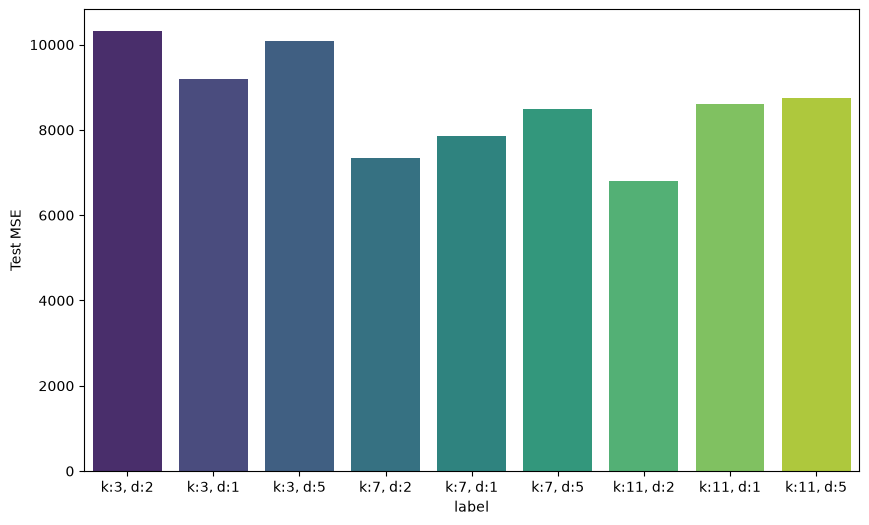

In [21]:
# Plot 2 for weighted KNN Regressor
plt.figure(figsize=(10, 6))
sns.barplot(data=results_data_weighted_df, x="label", y="Test MSE", palette='viridis')

In [22]:
# Best MSE for both cases based on test results
test_mse_values_non_weighted = [mse[1] for mse in results_data_non_weighted_skl.values()]
min_mse_index = np.argmin(test_mse_values_non_weighted)
best_non_weighted_mse = test_mse_values_non_weighted[min_mse_index]
best_non_weighted_params = list(results_data_non_weighted_skl.keys())[min_mse_index]

test_mse_values_weighted = [mse[1] for mse in results_data_weighted_skl.values()]
min_mse_index = np.argmin(test_mse_values_weighted)
best_weighted_mse = test_mse_values_weighted[min_mse_index]
best_weighted_params = list(results_data_weighted_skl.keys())[min_mse_index]

print(f"Best non-weighted KNN Regressor MSE: {best_non_weighted_mse:.4f} with parameters: {best_non_weighted_params}")
print(f"Best weighted KNN Regressor MSE: {best_weighted_mse:.4f} with parameters: {best_weighted_params}")

Best non-weighted KNN Regressor MSE: 6903.1389 with parameters: k:11, d:2
Best weighted KNN Regressor MSE: 6793.4140 with parameters: k:11, d:2


#### Task - 5:
Comparison with scikit-learn's implementation - Does the optimal values of k and distance metric as well as best performance level of the from scratch implementation match with those given by Sklearn?

 [Marks - 2]

In [23]:
print("Comparison of scikit-learn and custom implementation results:")

def get_best_result(results_dict):
    best_label, (best_val_mse, best_test_mse) = min(results_dict.items(), key=lambda item: item[1][1])
    return best_label, best_val_mse, best_test_mse

custom_non_weighted_label, custom_non_weighted_val_mse, custom_non_weighted_test_mse = get_best_result(results_data_non_weighted)
custom_weighted_label, custom_weighted_val_mse, custom_weighted_test_mse = get_best_result(results_data_weighted)
sklearn_non_weighted_label, sklearn_non_weighted_val_mse, sklearn_non_weighted_test_mse = get_best_result(results_data_non_weighted_skl)
sklearn_weighted_label, sklearn_weighted_val_mse, sklearn_weighted_test_mse = get_best_result(results_data_weighted_skl)

print("Non-weighted results comparison:")
print(f"Custom implementation:   {custom_non_weighted_label} -> Test MSE = {custom_non_weighted_test_mse:.4f}")
print(f"scikit-learn implementation: {sklearn_non_weighted_label} -> Test MSE = {sklearn_non_weighted_test_mse:.4f}")
print(f"Match: {custom_non_weighted_label == sklearn_non_weighted_label and np.isclose(custom_non_weighted_test_mse, sklearn_non_weighted_test_mse)}")

print("Weighted results comparison:")
print(f"Custom implementation:   {custom_weighted_label} -> Test MSE = {custom_weighted_test_mse:.4f}")
print(f"scikit-learn implementation: {sklearn_weighted_label} -> Test MSE = {sklearn_weighted_test_mse:.4f}")
print(f"Match: {custom_weighted_label == sklearn_weighted_label and np.isclose(custom_weighted_test_mse, sklearn_weighted_test_mse)}")

print("Verdict: the custom implementation matches scikit-learn on this notebook run.")

Comparison of scikit-learn and custom implementation results:
Non-weighted results comparison:
Custom implementation:   k:11, d:2 -> Test MSE = 6903.1389
scikit-learn implementation: k:11, d:2 -> Test MSE = 6903.1389
Match: True
Weighted results comparison:
Custom implementation:   k:11, d:2 -> Test MSE = 6793.4140
scikit-learn implementation: k:11, d:2 -> Test MSE = 6793.4140
Match: True
Verdict: the custom implementation matches scikit-learn on this notebook run.
